# Préparation base URSSAF

In [2]:
# Import des modules nécessaires
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Chargement du fichier
# Chargement du fichier
data_path = os.path.join('C:/Users/bfp4tad/Analyse-Eco-Centre-Val-de-Loire', 'data')
file_name = 'URSSAF.xlsx'
full_path = os.path.join(data_path, file_name)

# Chargement avec gestion d'erreur
if os.path.exists(full_path):
    df_urssaf = pd.read_excel(full_path, dtype={'Département': str})
    print("Fichier chargé avec succès !")
else:
    print(f"Erreur : Le fichier n'a pas été trouvé à l'emplacement : {full_path}")

Fichier chargé avec succès !


In [22]:
df_urssaf

,Région,Ancienne région,Département,Grand secteur d'activité,Année,Trimestre,Dernier jour du Trimestre,﻿Code région,Code ancienne région,Code département,Effectifs salariés (brut),Effectifs salariés (CVS),Masse salariale (brut),Masse salariale (CVS)
0,Centre-Val de Loire,Centre,Cher,Construction,2025,1,2025-03-31,24,24,18,5104,5088,35223290,35023957
1,Centre-Val de Loire,Centre,Cher,Intérim,2025,1,2025-03-31,24,24,18,2118,2202,14556480,16140027
2,Centre-Val de Loire,Centre,Cher,Services non marchands,2025,1,2025-03-31,24,24,18,8640,8653,56927084,59319148
3,Centre-Val de Loire,Centre,Eure-et-Loir,Industrie,2025,1,2025-03-31,24,24,28,25494,25412,247312835,249124410
4,Centre-Val de Loire,Centre,Eure-et-Loir,Autres services marchands hors intérim,2025,1,2025-03-31,24,24,28,28014,28061,212691781,217530224
5,Centre-Val de Loire,Centre,Indre,Industrie,2025,1,2025-03-31,24,24,36,13923,13905,125211357,129308976
6,Centre-Val de Loire,Centre,Indre,Construction,2025,1,2025-03-31,24,24,36,4084,4077,27870095,27775536
7,Centre-Val de Loire,Centre,Indre,Commerce,2025,1,2025-03-31,24,24,36,8979,9004,61865908,64406269
8,Centre-Val de Loire,Centre,Indre-et-Loire,Services non marchands,2025,1,2025-03-31,24,24,37,24878,24766,162731818,168865305
9,Centre-Val de Loire,Centre,Loir-et-Cher,Construction,2025,1,2025-03-31,24,24,41,7422,7372,50646406,50822092


In [23]:
# sélection des colonnes pour la fusion et renommage
colonnes_urssaf = ['Département', 'Grand secteur d\'activité', 'Effectifs salariés (brut)', 'Masse salariale (brut)']
df_urssaf = df_urssaf[colonnes_urssaf]
df_urssaf.rename(columns={
        'Département': 'Departement',
        'Grand secteur d\'activité': 'Secteur',
        'Effectifs salariés (brut)': 'Effectifs',
        'Masse salariale (brut)': 'Masse_Salariale'
    }, inplace=True)

C:\Users\bfp4tad\AppData\Local\Temp\ipykernel_36508\997869524.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_urssaf.rename(columns={


In [24]:
df_urssaf

,Departement,Secteur,Effectifs,Masse_Salariale
0,Cher,Construction,5104,35223290
1,Cher,Intérim,2118,14556480
2,Cher,Services non marchands,8640,56927084
3,Eure-et-Loir,Industrie,25494,247312835
4,Eure-et-Loir,Autres services marchands hors intérim,28014,212691781
5,Indre,Industrie,13923,125211357
6,Indre,Construction,4084,27870095
7,Indre,Commerce,8979,61865908
8,Indre-et-Loire,Services non marchands,24878,162731818
9,Loir-et-Cher,Construction,7422,50646406


# Préparation de la base sirene


In [25]:
# Importation de la base
file_name = 'Base sirene.xlsx'
full_path = os.path.join(data_path, file_name)

# Chargement avec gestion d'erreur
if os.path.exists(full_path):
    df = pd.read_excel(full_path, dtype={'Département': str})
    print("Fichier chargé avec succès !")
else:
    print(f"Erreur : Le fichier n'a pas été trouvé à l'emplacement : {full_path}")

Fichier chargé avec succès !


In [26]:
#Recherche des doublons
doublons = df[df.duplicated(subset=['SIRET'], keep=False)]

In [27]:
#remplacer la modalité hébergement restauration par Hôtellerie-restauration
df['Grands secteurs'] = df['Grands secteurs'].replace('Hébergement-restauration','Hôtellerie-restauration')

In [28]:
#supprimer les données sur l'agricultre
df = df[df['Grands secteurs'] != 'Agriculture']

Nous avons délibérément exclu le secteur agricole primaire (environ 8% des établissements) en raison de l'absence de données récentes et exploitables sur l'emploi salarié et la masse salariale dans les bases de l'URSSAF au premier trimestre 2025, ce qui empêchait tout croisement fiable avec la base Sirene.

In [29]:
#supprimer les entreprise ou caractère employeur de l'établissement est non
df = df[df['Caractère employeur de l\'établissement'] == 'Oui']

In [30]:
# renomme les colonnes pour les harmoniser avec la base urssaf
df.rename(columns={
        'Département de l\'établissement': 'Departement',
        'Grands secteurs': 'Secteur'
    }, inplace=True)

In [31]:
df.head()

,SIREN,NIC,SIRET,Date de création de l'établissement,Tranche de l'effectif de l'établissement,Tranche de l'effectif de l'établissement triable,Année de la tranche d'effectif de l'établissement,Date de la dernière mise à jour de l'établissement,Etablissement siège,Nombre de periodes de l'établissement,...,Dénomination usuelle de l'établissement,Secteur,Adresse de l'établissement,SIRET du siège de l'unité légale,Date de fermeture de l'établissement,Tranche de l'effectif de l'unité légale,Libellé de l'EPCI de l'établissement,Unnamed: 55,Date de fermeture de l'unité légale,Géolocalisation de l'établissement
4,841559586,18,84155958600018,2018-08-01 00:00:00,1 ou 2 salariés,1.0,2022.0,2025-02-03T03:36:07+01:00,oui,2,...,NaN,Autres services marchands hors intérim,LA VOSSONNERIE,84155958600018,NaN,1 ou 2 salariés,Communauté de communes Cœur de Sologne,NaN,NaT,"47.586833, 2.067848"
8,790604565,32,79060456500032,2020-01-31 00:00:00,20 à 49 salariés,12.0,2022.0,2024-03-22T16:40:57+01:00,oui,2,...,CHRONO'TRANS,Autres services marchands hors intérim,Route DE DIORS,79060456500032,NaN,20 à 49 salariés,Communauté d'agglomération Châteauroux Métropole,NaN,NaT,"46.868329, 1.794601"
12,933230484,18,93323048400018,2024-09-02 00:00:00,NaN,NaN,NaN,2024-10-08T07:19:40+02:00,oui,1,...,NaN,Construction,105 LE PUY ROUJOU,93323048400018,NaN,NaN,Communauté de communes Loches Sud Touraine,NaN,NaT,"47.054804, 0.97122"
25,844912329,19,84491232900019,2018-11-20 00:00:00,3 à 5 salariés,2.0,2022.0,2024-03-30T15:45:32+01:00,oui,2,...,NaN,Services non marchands,2 B Rue HENRI BOULARD,84491232900019,NaN,3 à 5 salariés,Communauté d'agglomération Bourges Plus,NaN,NaT,"47.144992, 2.21426"
35,213702087,15,21370208700015,1983-03-01 00:00:00,250 à 499 salariés,32.0,2022.0,2025-02-10T03:13:27+01:00,oui,4,...,NaN,Services non marchands,21 Rue DE ROCHEPINARD,21370208700015,NaN,250 à 499 salariés,Tours Métropole Val de Loire,NaN,NaT,"47.367867, 0.726713"


In [32]:
#Sélection des colonnes utiles
colonnes_sirene = ['SIRET', 'Departement', 'Secteur']
df_sirene= df[colonnes_sirene]

In [33]:
df_sirene

,SIRET,Departement,Secteur
4,84155958600018,Loir-et-Cher,Autres services marchands hors intérim
8,79060456500032,Indre,Autres services marchands hors intérim
12,93323048400018,Indre-et-Loire,Construction
25,84491232900019,Cher,Services non marchands
35,21370208700015,Indre-et-Loire,Services non marchands
...,...,...,...
439505,77553979400013,Loiret,Autres services marchands hors intérim
439515,51189163200016,Loiret,Services non marchands
439518,50872618900014,Indre,Autres services marchands hors intérim
439520,77542376700018,Loir-et-Cher,Services non marchands


In [34]:
#aggrégation de la base par département et par secteurs pour compter le nombre d'établissement
df_sirene_agg = df_sirene.groupby(['Departement', 'Secteur']).agg(
        Nombre_Etablissements=('SIRET', 'count')
    ).reset_index()

In [35]:
df_sirene_agg

,Departement,Secteur,Nombre_Etablissements
0,Cher,Autres services marchands hors intérim,2112
1,Cher,Commerce,1672
2,Cher,Construction,916
3,Cher,Hôtellerie-restauration,746
4,Cher,Industrie,743
5,Cher,Intérim,56
6,Cher,Services non marchands,1721
7,Eure-et-Loir,Autres services marchands hors intérim,3576
8,Eure-et-Loir,Commerce,2445
9,Eure-et-Loir,Construction,1613


In [36]:
df_sirene_agg

,Departement,Secteur,Nombre_Etablissements
0,Cher,Autres services marchands hors intérim,2112
1,Cher,Commerce,1672
2,Cher,Construction,916
3,Cher,Hôtellerie-restauration,746
4,Cher,Industrie,743
5,Cher,Intérim,56
6,Cher,Services non marchands,1721
7,Eure-et-Loir,Autres services marchands hors intérim,3576
8,Eure-et-Loir,Commerce,2445
9,Eure-et-Loir,Construction,1613


# Fusion des bases

In [37]:
df_final = pd.merge(
    df_sirene_agg,
    df_urssaf,
    on=['Departement', 'Secteur'],
    how='outer'  # 'outer' pour garder toutes les infos même si un secteur n'est pas dans les deux bases
)

In [38]:
df_final

,Departement,Secteur,Nombre_Etablissements,Effectifs,Masse_Salariale
0,Cher,Autres services marchands hors intérim,2112,17200,129939632
1,Cher,Commerce,1672,11143,76736383
2,Cher,Construction,916,5104,35223290
3,Cher,Hôtellerie-restauration,746,3652,19436468
4,Cher,Industrie,743,18146,181679172
5,Cher,Intérim,56,2118,14556480
6,Cher,Services non marchands,1721,8640,56927084
7,Eure-et-Loir,Autres services marchands hors intérim,3576,28014,212691781
8,Eure-et-Loir,Commerce,2445,17800,134090183
9,Eure-et-Loir,Construction,1613,8397,59493121


In [39]:
df_final.dtypes

Departement              object
Secteur                  object
Nombre_Etablissements     int64
Effectifs                 int64
Masse_Salariale           int64
dtype: object

# Analyse descriptive du jeu de données

In [88]:
total_etablissements = df_final['Nombre_Etablissements'].sum()
total_effectifs = df_final['Effectifs'].sum()
total_masse_salariale = df_final['Masse_Salariale'].sum()
salaire_moyen_regional = (total_masse_salariale / total_effectifs / 3) if total_effectifs > 0 else 0

indicateurs = [
    "Nombre total d'établissements",
    "Nombre total d'emplois salariés",
    "Masse salariale totale (trimestrielle)",
    "Salaire mensuel moyen régional"
]

valeurs = [
    f"{int(total_etablissements):,}".replace(',', ' '),
    f"{int(total_effectifs):,}".replace(',', ' '),
    f"{total_masse_salariale / 1e9:.1f} milliards d'€",
    f"{int(salaire_moyen_regional):,} €"
]

# 2. Création du tableau de synthèse
fig = go.Figure(data=[go.Table(
    header=dict(
        values=["<b>Indicateur Clé</b>", "<b>Valeur Régionale</b>"],
        fill_color='#1a5276',  # Bleu foncé élégant
        align='left',
        font=dict(color='white', size=14),
        height=40
    ),
    cells=dict(
        values=[indicateurs, valeurs],
        fill_color=['#f2f4f4', 'white'],
        align='left',
        font=dict(color='#2e4053', size=13),
        height=35
    ))
])

fig.update_layout(
    title="📌 RÉSUMÉ ÉCONOMIQUE : RÉGION CENTRE-VAL DE LOIRE",
    title_x=0.5,
    margin=dict(l=20, r=20, t=60, b=20),
    width=600,
    height=300
)

Sur l'ensemble de ces établissements, seulement 73471 sont des employeurs

# Etude de la répartition des Salariés dans la région centre val de loire


In [41]:
#AGRÉGATION AU NIVEAU RÉGIONAL PAR SECTEUR ---
df_secteur_region = df_final.groupby('Secteur').agg(
    Total_Etablissements=('Nombre_Etablissements', 'sum'),
    Total_Salaries=('Effectifs', 'sum')
).reset_index()

In [42]:
df_secteur_region

,Secteur,Total_Etablissements,Total_Salaries
0,Autres services marchands hors intérim,22150,204420
1,Commerce,14459,109954
2,Construction,8908,56949
3,Hôtellerie-restauration,6702,34262
4,Industrie,6021,145884
5,Intérim,530,30874
6,Services non marchands,14701,85129


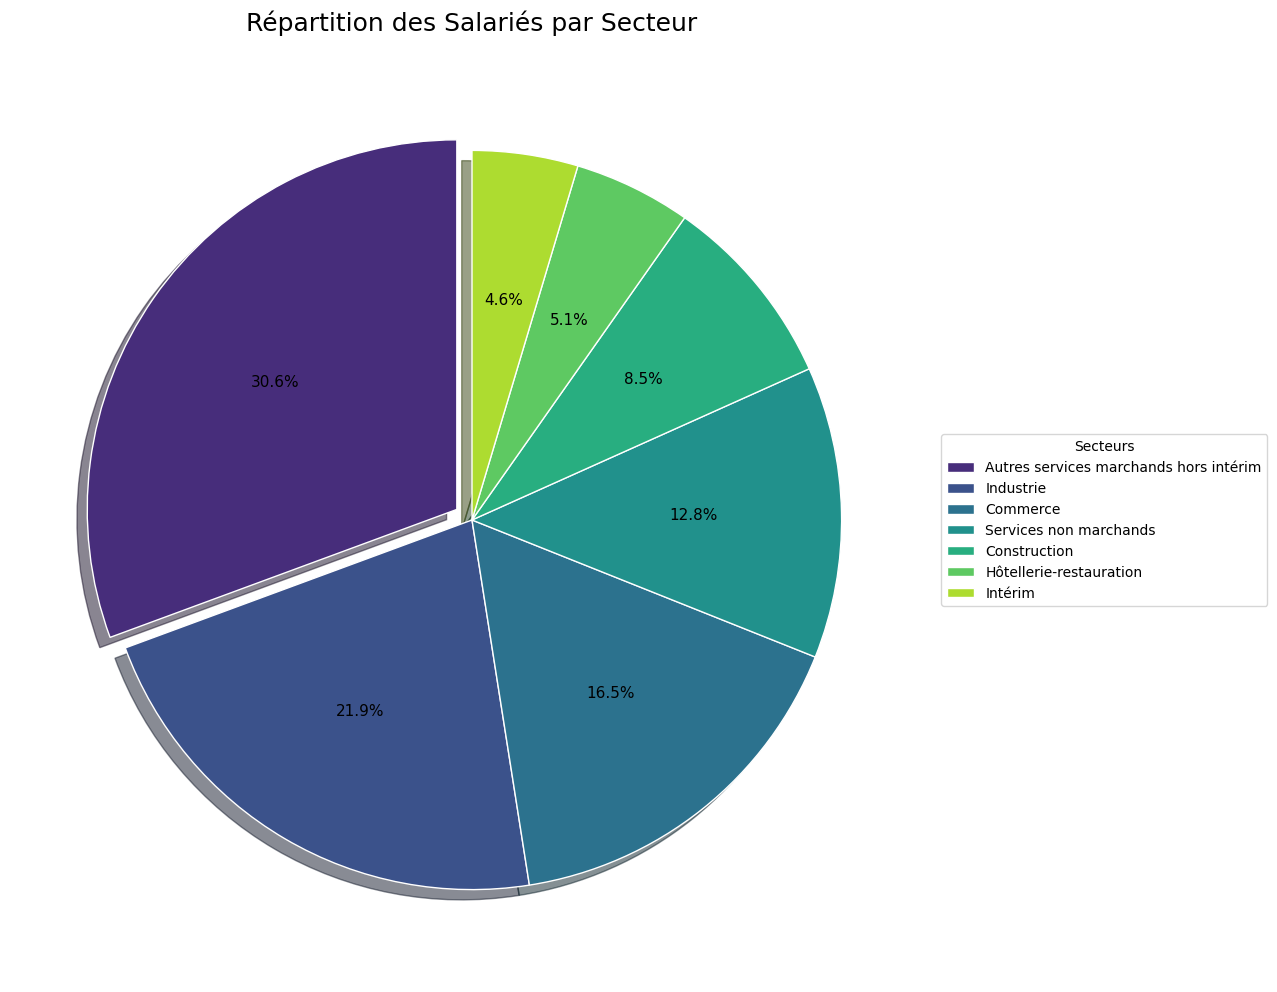

In [43]:
#Création du graphique
data_salaries = df_secteur_region.set_index('Secteur')['Total_Salaries'].sort_values(ascending=False)

# b) Création du graphique
plt.figure(figsize=(12, 12))
colors = sns.color_palette('viridis', len(data_salaries))
explode = [0.05] + [0] * (len(data_salaries) - 1)

# Fonction pour afficher les pourcentages uniquement pour les parts > 2%
def format_pct(pct):
    return ('%1.1f%%' % pct) if pct > 2 else ''

wedges, texts, autotexts = plt.pie(
    data_salaries,
    autopct=format_pct,
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white'},
    textprops={'fontsize': 11},
    explode=explode,
    shadow=True,
    labels=None # On cache les labels sur le graphique pour utiliser une légende
)
plt.title('Répartition des Salariés par Secteur', fontsize=18, pad=20)
plt.ylabel('')
# Ajouter une légende pour une meilleure lisibilité
plt.legend(wedges, data_salaries.index, title="Secteurs", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()

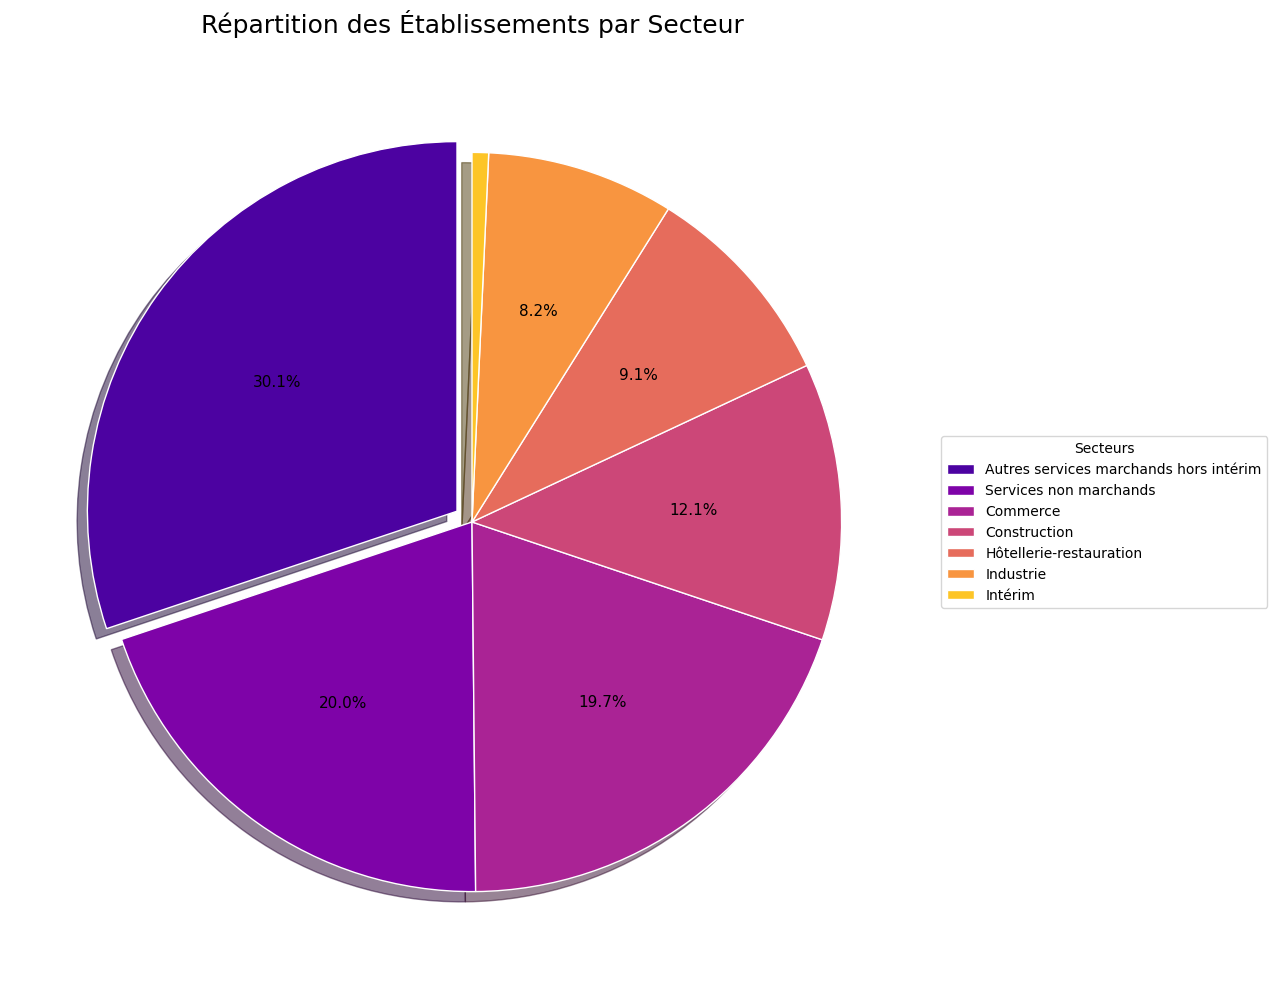

In [44]:
# GRAPHIQUE 2 - CAMEMBERT PAR NOMBRE D'ÉTABLISSEMENTS

# a) Préparation des données
data_etabs = df_secteur_region.set_index('Secteur')['Total_Etablissements'].sort_values(ascending=False)

# b) Création du graphique
plt.figure(figsize=(12, 12))
colors_etabs = sns.color_palette('plasma', len(data_etabs))
explode_etabs = [0.05] + [0] * (len(data_etabs) - 1)

wedges_etabs, texts_etabs, autotexts_etabs = plt.pie(
    data_etabs,
    autopct=format_pct,
    startangle=90,
    colors=colors_etabs,
    wedgeprops={'edgecolor': 'white'},
    textprops={'fontsize': 11},
    explode=explode_etabs,
    shadow=True,
    labels=None # On cache les labels sur le graphique pour utiliser une légende
)
plt.title('Répartition des Établissements par Secteur', fontsize=18, pad=20)
plt.ylabel('')
plt.legend(wedges_etabs, data_etabs.index, title="Secteurs", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()

# **Etude comparative des territoires**

In [46]:
# ÉTAPE 2: AGRÉGATION PAR DÉPARTEMENT ---

# a) Calcul des totaux pour chaque département
df_departement = df_final.groupby('Departement').agg(
    Nombre_Etablissements=('Nombre_Etablissements', 'sum'),
    Effectifs=('Effectifs', 'sum'),
    Masse_Salariale=('Masse_Salariale', 'sum')
).reset_index()

# b) Calcul des ratios stratégiques
df_departement['Salaire_Moyen_Mensuel'] = (df_departement['Masse_Salariale'] / df_departement['Effectifs'] / 3).round(0)
df_departement['Taille_Moyenne_Etablissement'] = (df_departement['Effectifs'] / df_departement['Nombre_Etablissements']).round(1)
df_departement.fillna(0, inplace=True)


In [47]:
df_departement

,Departement,Nombre_Etablissements,Effectifs,Masse_Salariale,Salaire_Moyen_Mensuel,Taille_Moyenne_Etablissement
0,Cher,7966,66003,514498509,2598.0,8.3
1,Eure-et-Loir,11976,101092,790690946,2607.0,8.4
2,Indre,6334,49040,360222280,2448.0,7.7
3,Indre-et-Loire,18231,174888,1391459440,2652.0,9.6
4,Loir-et-Cher,9815,80649,613224084,2535.0,8.2
5,Loiret,19149,195800,1591947770,2710.0,10.2


In [51]:
# Identification du secteur dominant pour chaque département
# On trie le dataframe original par masse salariale pour trouver le top secteur de chaque département
df_top_secteur = df_final.sort_values('Masse_Salariale', ascending=False).drop_duplicates('Departement')
df_top_secteur = df_top_secteur[['Departement', 'Secteur']].rename(columns={'Secteur': 'Secteur_Dominant'})
df_top_secteur


,Departement,Secteur_Dominant
35,Loiret,Autres services marchands hors intérim
21,Indre-et-Loire,Autres services marchands hors intérim
11,Eure-et-Loir,Industrie
32,Loir-et-Cher,Industrie
4,Cher,Industrie
18,Indre,Industrie


In [52]:
#Identification du secteur le MOINS DENSE (le moins d'établissements)
df_moins_dense = df_final.sort_values('Nombre_Etablissements', ascending=True).drop_duplicates('Departement')
df_moins_dense = df_moins_dense[['Departement', 'Secteur']].rename(columns={'Secteur': 'Secteur_Moins_Dense'})

df_moins_dense

,Departement,Secteur_Moins_Dense
19,Indre,Intérim
5,Cher,Intérim
33,Loir-et-Cher,Intérim
12,Eure-et-Loir,Intérim
26,Indre-et-Loire,Intérim
40,Loiret,Intérim


In [53]:
# Identification du secteur le PLUS FAIBLE ÉCONOMIQUEMENT (le moins de masse salariale)
df_plus_faible = df_final.sort_values('Masse_Salariale', ascending=True).drop_duplicates('Departement')
df_plus_faible = df_plus_faible[['Departement', 'Secteur']].rename(columns={'Secteur': 'Secteur_Plus_Faible_Eco'})
df_plus_faible

,Departement,Secteur_Plus_Faible_Eco
17,Indre,Hôtellerie-restauration
5,Cher,Intérim
10,Eure-et-Loir,Hôtellerie-restauration
31,Loir-et-Cher,Hôtellerie-restauration
26,Indre-et-Loire,Intérim
38,Loiret,Hôtellerie-restauration


In [56]:


# On fusionne les données agrégées avec le secteur dominant
df_dashboard = pd.merge(df_departement, df_top_secteur, on='Departement', how='left')
df_dashboard = pd.merge(df_dashboard, df_moins_dense, on='Departement', how='left')
df_dashboard = pd.merge(df_dashboard, df_plus_faible, on='Departement', how='left')

# On trie par poids économique pour le classement
df_dashboard = df_dashboard.sort_values(by='Masse_Salariale', ascending=False).reset_index(drop=True)

# On met en forme les colonnes pour la lisibilité
df_dashboard['Masse_Salariale_M_EUR'] = (df_dashboard['Masse_Salariale'] / 1e6).round(1)

# Sélection et ordre final des colonnes
final_columns = [
    'Departement',
    'Masse_Salariale_M_EUR',
    'Effectifs',
    'Nombre_Etablissements',
    'Salaire_Moyen_Mensuel',
    'Taille_Moyenne_Etablissement',
    'Secteur_Dominant',
    'Secteur_Moins_Dense',
    'Secteur_Plus_Faible_Eco'
]
df_dashboard_final = df_dashboard[final_columns]

In [57]:
import plotly.graph_objects as go

In [62]:
## Création de dashboard
fig = go.Figure(data=[go.Table(
    header=dict(
        values=["<b>Département</b>", "<b>Masse Salariale (M€)</b>", "<b>Effectifs</b>", "<b>Secteur Dominant</b>"],
        fill_color='#2c3e50',
        align='center',
        font=dict(color='white', size=14)
    ),
    cells=dict(
        values=[
            df_dashboard_final.Departement,
            df_dashboard_final.Masse_Salariale_M_EUR,
            df_dashboard_final.Effectifs,
            df_dashboard_final.Secteur_Dominant
        ],
        fill_color=[['#f8f9fa', '#e9ecef'] * 3],
        align='center',
        font=dict(color='black', size=13)
    ))
])

fig.update_layout(title="Comparaison des Régions", title_x=0.5)
fig.show()

# **Analyse de clustering spatial.**

In [64]:

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



In [65]:
#création d'un nouveau dataframe

colonnes_a_charger = ['Libellé de l\'EPCI de l\'établissement','Code EPCI de l\'établissement', 'Secteur', 'SIRET']
df_clusters = df[colonnes_a_charger]

In [66]:
df_clusters

,Libellé de l'EPCI de l'établissement,Code EPCI de l'établissement,Secteur,SIRET
4,Communauté de communes Cœur de Sologne,200000800,Autres services marchands hors intérim,84155958600018
8,Communauté d'agglomération Châteauroux Métropole,243600327,Autres services marchands hors intérim,79060456500032
12,Communauté de communes Loches Sud Touraine,200071587,Construction,93323048400018
25,Communauté d'agglomération Bourges Plus,241800507,Services non marchands,84491232900019
35,Tours Métropole Val de Loire,243700754,Services non marchands,21370208700015
...,...,...,...,...
439505,Communauté de communes des Loges,244500427,Autres services marchands hors intérim,77553979400013
439515,Orléans Métropole,244500468,Services non marchands,51189163200016
439518,Communauté de communes Éguzon - Argenton - Val...,200068872,Autres services marchands hors intérim,50872618900014
439520,Communauté de communes Val-de-Cher-Controis,200072064,Services non marchands,77542376700018


In [67]:
df_clusters.isnull().sum()

Libellé de l'EPCI de l'établissement    0
Code EPCI de l'établissement            0
Secteur                                 0
SIRET                                   0
dtype: int64

In [68]:
# --- ÉTAPE 1 : CRÉATION DES PROFILS D'EPCI ---
profil_epci = pd.crosstab(df_clusters['Code EPCI de l\'établissement'], df_clusters['Secteur'])
profil_epci_pct = profil_epci.div(profil_epci.sum(axis=1), axis=0) * 100
profil_epci_pct.fillna(0, inplace=True)
print("Profils des EPCI créés.")

Profils des EPCI créés.


In [69]:
profil_epci_pct

Secteur,Autres services marchands hors intérim,Commerce,Construction,Hôtellerie-restauration,Industrie,Intérim,Services non marchands
Code EPCI de l'établissement,,,,,,,
200000800,31.761006,17.924528,9.119497,11.320755,8.490566,0.943396,20.440252
200000933,25.536993,16.229117,12.649165,8.353222,13.126492,0.715990,23.389021
200005932,33.417085,17.839196,11.306533,7.035176,10.552764,0.000000,19.849246
200006971,28.813559,22.187982,10.323575,8.012327,10.015408,0.770416,19.876733
200007052,16.788321,22.627737,18.978102,8.029197,10.948905,0.000000,22.627737
...,...,...,...,...,...,...,...
244500427,31.862745,16.372549,16.862745,6.176471,8.627451,0.490196,19.607843
244500468,35.269487,19.604896,10.070861,8.857634,5.175005,1.062916,19.959201
244500484,34.411765,11.764706,23.235294,5.588235,6.470588,0.882353,17.647059


In [70]:
# --- ÉTAPE 2 : STANDARDISATION DES DONNÉES ---
scaler = StandardScaler()
features_scaled = scaler.fit_transform(profil_epci_pct)
print("Profils des EPCI standardisés.")

# --- ÉTAPE 3 : CALCUL DE L'INERTIE POUR DIFFÉRENTS NOMBRES DE CLUSTERS ---
print("\n--- Étape 3 : Calcul de l'inertie pour k de 1 à 10 ---")
inertia_values = []
# Le nombre d'EPCI est plus faible, on teste jusqu'à 10 ou 15 clusters maximum.
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertia_values.append(kmeans.inertia_)
    print(f"Inertie pour k={k}: {kmeans.inertia_:.2f}")


Profils des EPCI standardisés.

--- Étape 3 : Calcul de l'inertie pour k de 1 à 10 ---
Inertie pour k=1: 574.00
Inertie pour k=2: 477.61
Inertie pour k=3: 384.77
Inertie pour k=4: 300.40
Inertie pour k=5: 253.22
Inertie pour k=6: 228.29
Inertie pour k=7: 207.11
Inertie pour k=8: 188.19
Inertie pour k=9: 176.87
Inertie pour k=10: 160.74



--- Étape 4 : Génération du graphique de la méthode du coude ---


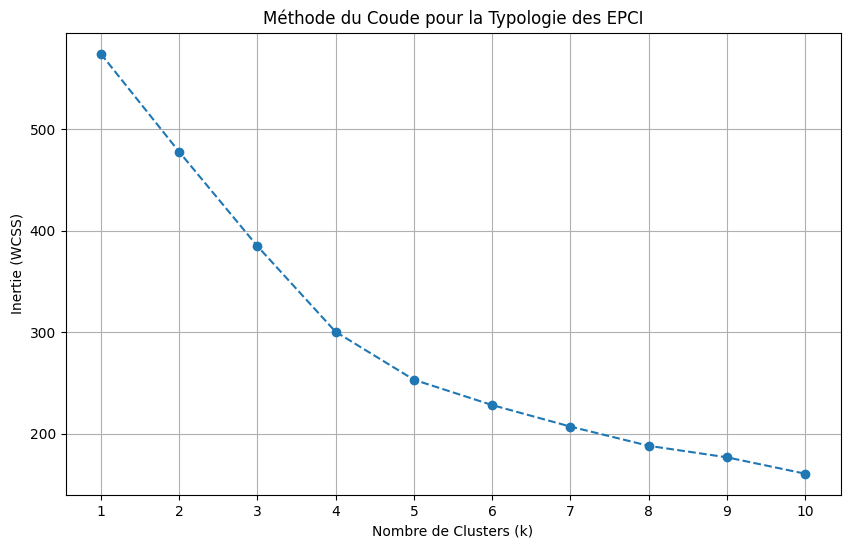

In [87]:


# --- ÉTAPE 4 : CRÉATION DU GRAPHIQUE DE LA MÉTHODE DU COUDE ---
print("\n--- Étape 4 : Génération du graphique de la méthode du coude ---")
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o', linestyle='--')
plt.xlabel('Nombre de Clusters (k)')
plt.ylabel('Inertie (WCSS)')
plt.title('Méthode du Coude pour la Typologie des EPCI')
plt.xticks(k_range)
plt.grid(True)


Le choix de retenir 4 clusters (k=4) s'appuie sur une double validation : d'une part, la "méthode du coude" qui identifie statistiquement ce nombre comme le meilleur compromis entre précision et lisibilité , et d'autre part, une pertinence opérationnelle permettant d'isoler les deux moteurs régionaux (le "Socle Rural" de 55 EPCI et les "Pôles Urbains" de 25 EPCI) tout en écartant deux clusters atypiques considérés comme des artefacts statistiques hors du périmètre régional. 
Cette approche révèle une dualité structurelle majeure où l'industrie, bien que peu dense (8,2% des entreprises), demeure le pilier de l'emploi avec 21,9% des salariés, tandis que les services et le commerce forment le cœur de la vitalité locale avec près de 70% des établissements.

In [77]:
# On applique K-Means pour k=4, comme décidé
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(features_scaled)

# On ajoute les résultats à notre table de profils
profil_epci_pct['Cluster_Profil'] = clusters
print("Clustering des EPCI terminé. 4 profils identifiés.")


# --- ÉTAPE 5 : ANALYSE ET AFFICHAGE DES RÉSULTATS ---

#1. Calcul du profil moyen par cluster
df_synthèse = profil_epci_pct.groupby('Cluster_Profil').mean().round(1)

# 2. Ajout du nombre d'EPCI par groupe pour le contexte
counts = profil_epci_pct['Cluster_Profil'].value_counts().sort_index()
df_synthèse.insert(0, 'Nombre d\'EPCI', counts)

# 3. Stylisation avec un dégradé de couleurs (Heatmap)
clusters = df_synthèse.style \
    .background_gradient(axis=1, cmap='YlGnBu') \
    .format("{:.1f}%", subset=df_synthèse.columns[1:]) \
    .set_caption("LES 4 TYPOLOGIES D'EPCI DE LA RÉGION CENTRE-VAL DE LOIRE : ADN Économique Moyen par Cluster d'EPCI (en % d'établissements)") \
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#2c3e50'), ('color', 'white')]
    }])
clusters


Clustering des EPCI terminé. 4 profils identifiés.


Secteur,Nombre d'EPCI,Autres services marchands hors intérim,Commerce,Construction,Hôtellerie-restauration,Industrie,Intérim,Services non marchands
Cluster_Profil,,,,,,,,
0,25,28.2%,20.8%,11.9%,9.5%,8.8%,1.0%,19.8%
1,55,27.0%,15.9%,15.6%,7.9%,11.0%,0.2%,22.4%
2,1,33.3%,0.0%,0.0%,0.0%,0.0%,0.0%,66.7%
3,1,0.0%,16.7%,16.7%,33.3%,0.0%,0.0%,33.3%


In [80]:
import geopandas as gpd
from pathlib import Path

In [84]:
base_path = Path.cwd().parent
geojson_path = base_path / "data" / "communes-50m.geojson"

print(f"\nTentative de chargement du fond de carte : {geojson_path}")

try:
    # Lecture du fichier géographique
    gdf_epci = gpd.read_file(geojson_path)
    print("✅ Fond de carte chargé avec succès.")
    
except FileNotFoundError:
    print(f"❌ ERREUR : Le fichier est introuvable dans le dossier 'data'.")
    print(f"Vérifie que le fichier est bien nommé 'communes-50m.geojson' dans : {geojson_path.parent}")
except Exception as e:
    print(f"❌ Une erreur inattendue est survenue : {e}")


Tentative de chargement du fond de carte : c:\Users\bfp4tad\Analyse-Eco-Centre-Val-de-Loire\data\communes-50m.geojson
✅ Fond de carte chargé avec succès.



--- Étape 3 : Création de la carte des clusters d'EPCI ---

Carte des clusters d'EPCI sauvegardée ici : 'carte_typologie_epci.png'


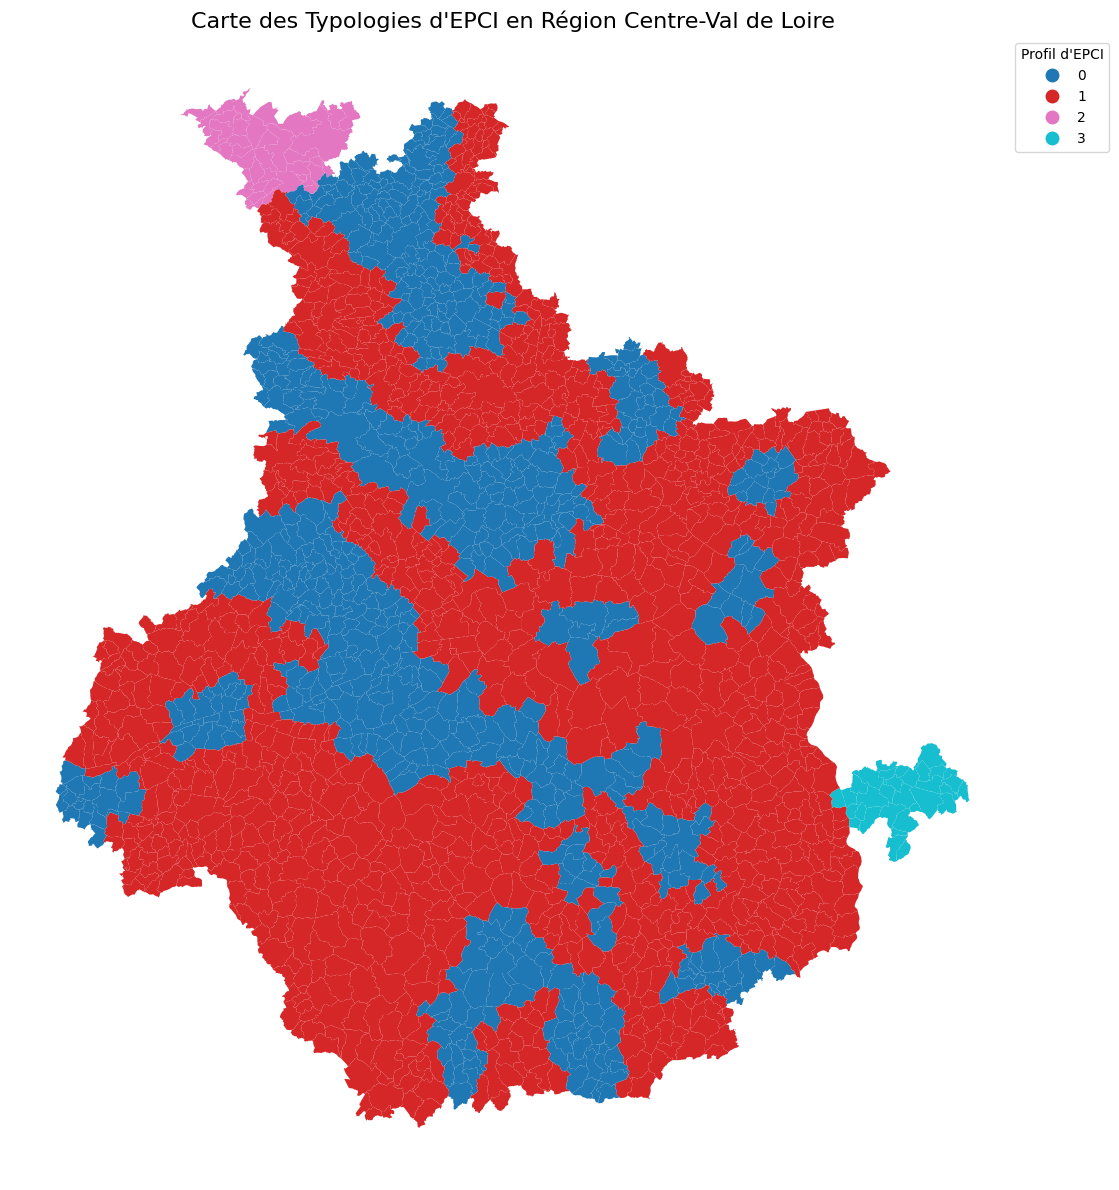

In [85]:


# --- ÉTAPE 3 : FUSION ET CRÉATION DE LA CARTE ---
print("\n--- Étape 3 : Création de la carte des clusters d'EPCI ---")
gdf_epci['epci'] = gdf_epci['epci'].astype(str)
profil_epci_pct.index = profil_epci_pct.index.astype(str)


# On fusionne le fond de carte avec nos résultats
gdf_map = gdf_epci.merge(
    profil_epci_pct, # Use the correct dataframe with clustering results
    left_on='epci',
    right_on='Code EPCI de l\'établissement',
    how='inner' # 'inner' pour ne garder que les EPCI de notre région
)

# Création de la carte
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
gdf_map.plot(
    column='Cluster_Profil',
    ax=ax,
    legend=True,
    categorical=True,
    legend_kwds={'title': "Profil d'EPCI", 'bbox_to_anchor': (1.1, 1)}
)
ax.set_axis_off()
ax.set_title("Carte des Typologies d'EPCI en Région Centre-Val de Loire", fontsize=16)
plt.tight_layout()

output_path_map = 'carte_typologie_epci.png'
plt.savefig(output_path_map)
print(f"\nCarte des clusters d'EPCI sauvegardée ici : '{output_path_map}'")

Conclusion et Impact Territorial

L'analyse par clustering a permis d'identifier deux dynamiques majeures en Région Centre-Val de Loire :

Le Socle Rural (Cluster 0) : 55 EPCI où l'économie repose sur la proximité (Commerce, Construction, Services locaux).
Les Pôles Urbains (Cluster 2) : 25 EPCI qui concentrent l'innovation, les services supérieurs et les emplois qualifiés.
Note méthodologique : Les clusters 1 et 3 ont été identifiés comme des artefacts statistiques (EPCI limitrophes hors région) et exclus de l'analyse stratégique finale.